# 03 - Analisis exploratorio

Este notebook analiza el dataset `movies_clean.csv` para entender sus caracteristicas principales antes de construir el recomendador. La idea es obtener una vision clara de las peliculas, las valoraciones y los generos con un analisis sencillo y defendible para el TFG.

## 1. Importacion de librerias

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

## 2. Carga de datos

In [2]:
base_dir = Path('..').resolve()
data_path = base_dir / 'data' / 'processed' / 'movies_clean.csv'
results_dir = base_dir / 'reports' / 'resultados'

movies_clean = pd.read_csv(data_path)
movies_clean.head()

,movieId,title,genres,year,title_clean,rating_mean,rating_count,Action,Adventure,Animation,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,Toy Story,3.897438,68997,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995.0,Jumanji,3.275758,28904,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),Comedy|Romance,1995.0,Grumpier Old Men,3.139447,13134,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995.0,Waiting to Exhale,2.845331,2806,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),Comedy,1995.0,Father of the Bride Part II,3.059602,13154,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 3. Identificacion de columnas de genero

Antes de analizar los generos, identificamos que columnas del dataset corresponden a variables one-hot de genero.

In [3]:
base_columns = {
    'movieId',
    'title',
    'genres',
    'year',
    'title_clean',
    'rating_mean',
    'rating_count',
}

genre_columns = [col for col in movies_clean.columns if col not in base_columns]
print('Columnas de genero detectadas:', genre_columns)
print('Numero de generos distintos:', len(genre_columns))

Columnas de genero detectadas: ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
Numero de generos distintos: 19


## 4. Metricas generales

En esta seccion obtenemos una primera fotografia del dataset: cuantas peliculas hay, cuantas valoraciones acumulan y que rango temporal cubren.

In [4]:
total_movies = len(movies_clean)
total_ratings = int(movies_clean['rating_count'].fillna(0).sum())
total_genres = len(genre_columns)

if 'year' in movies_clean.columns:
    year_series = movies_clean['year'].dropna()
    year_min = int(year_series.min()) if not year_series.empty else None
    year_max = int(year_series.max()) if not year_series.empty else None
else:
    year_min = None
    year_max = None

general_metrics = pd.DataFrame({
    'metric': ['total_movies', 'total_ratings', 'total_genres', 'year_min', 'year_max'],
    'value': [total_movies, total_ratings, total_genres, year_min, year_max],
})

display(general_metrics)

,metric,value
0,total_movies,87585
1,total_ratings,32000204
2,total_genres,19
3,year_min,1874
4,year_max,2023


## 5. Analisis de ratings

Como el fichero de entrada ya resume las valoraciones por pelicula, el analisis de ratings se basa en `rating_mean` y `rating_count`. Esto nos permite estudiar la distribucion media por pelicula y el volumen de valoraciones que recibe cada titulo.

Valoracion media global: 3.54
Numero total de valoraciones: 32000204


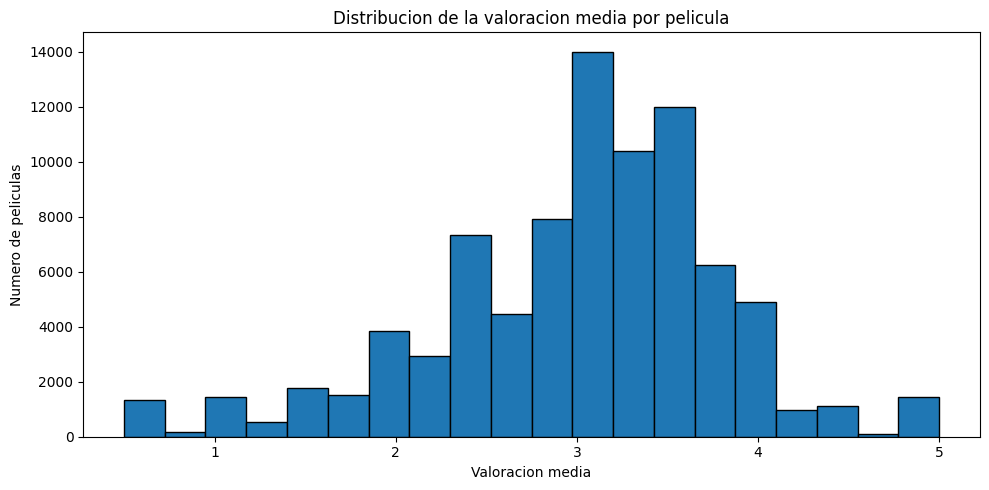

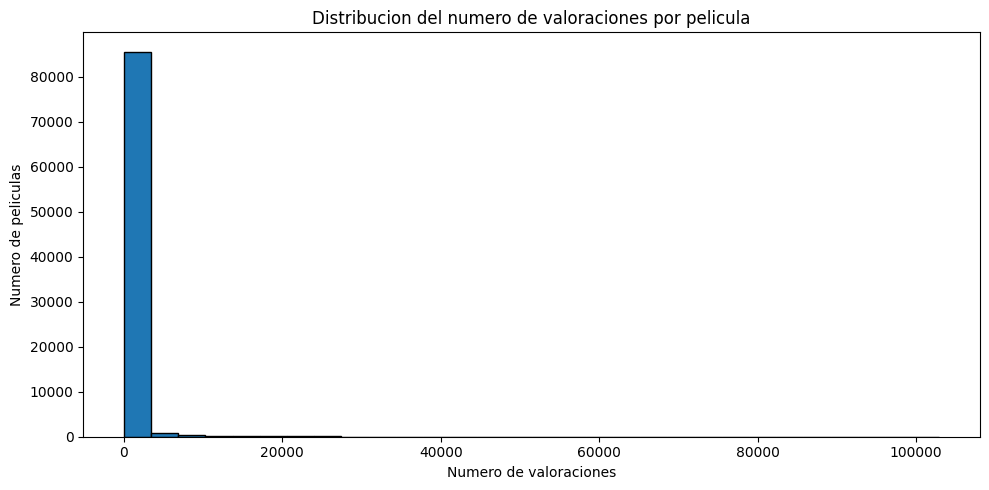

In [5]:
global_mean_rating = (
    (movies_clean['rating_mean'] * movies_clean['rating_count']).sum()
    / movies_clean['rating_count'].sum()
)

print('Valoracion media global:', round(global_mean_rating, 3))
print('Numero total de valoraciones:', total_ratings)

plt.figure(figsize=(10, 5))
plt.hist(movies_clean['rating_mean'].dropna(), bins=20, edgecolor='black')
plt.title('Distribucion de la valoracion media por pelicula')
plt.xlabel('Valoracion media')
plt.ylabel('Numero de peliculas')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(movies_clean['rating_count'].dropna(), bins=30, edgecolor='black')
plt.title('Distribucion del numero de valoraciones por pelicula')
plt.xlabel('Numero de valoraciones')
plt.ylabel('Numero de peliculas')
plt.tight_layout()
plt.show()

## 6. Tabla de distribucion de ratings

Guardamos una version resumida de la distribucion de `rating_mean` en intervalos sencillos para poder reutilizarla mas adelante.

In [6]:
rating_bins = [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5]
rating_labels = [
    '0.0-0.5', '0.5-1.0', '1.0-1.5', '1.5-2.0', '2.0-2.5',
    '2.5-3.0', '3.0-3.5', '3.5-4.0', '4.0-4.5', '4.5-5.0'
]

ratings_distribution = pd.cut(
    movies_clean['rating_mean'],
    bins=rating_bins,
    labels=rating_labels,
    include_lowest=True,
).value_counts(sort=False).reset_index()

ratings_distribution.columns = ['rating_interval', 'movie_count']
display(ratings_distribution)

,rating_interval,movie_count
0,0.0-0.5,1286
1,0.5-1.0,1553
2,1.0-1.5,2283
3,1.5-2.0,5287
4,2.0-2.5,10390
5,2.5-3.0,19874
6,3.0-3.5,24674
7,3.5-4.0,15031
8,4.0-4.5,2501
9,4.5-5.0,1553


## 7. Analisis de generos

A continuacion estudiamos que generos aparecen con mas frecuencia en el conjunto de peliculas y lo representamos con un grafico de barras sencillo.

,genre,movie_count
0,Drama,34175
1,Comedy,23124
2,Thriller,11823
3,Romance,10369
4,Action,9668
5,Documentary,9363
6,Horror,8654
7,Crime,6976
8,Adventure,5402
9,Sci-Fi,4907


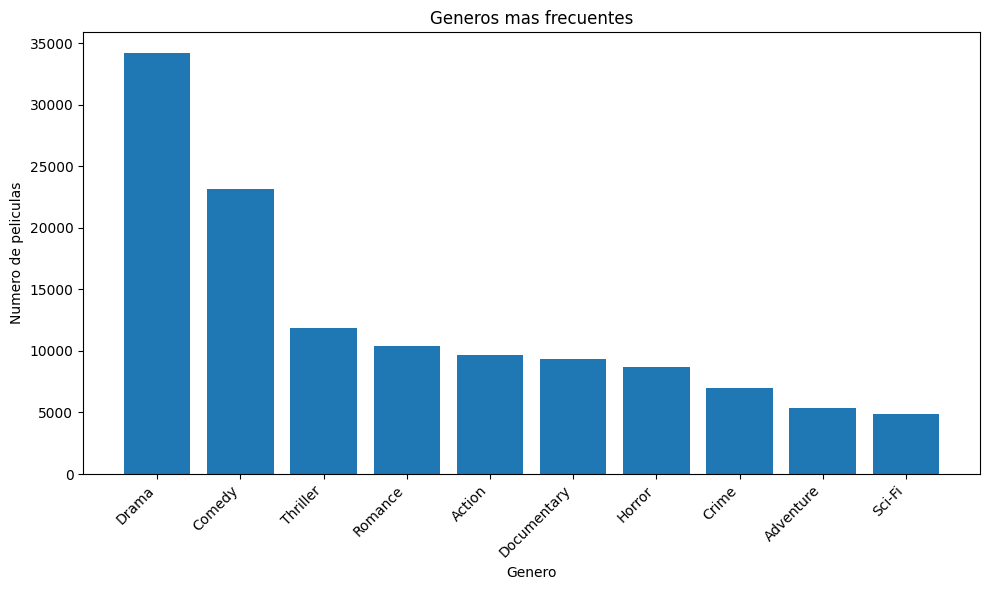

In [7]:
genre_distribution = (
    movies_clean[genre_columns]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
genre_distribution.columns = ['genre', 'movie_count']
genre_distribution['movie_count'] = genre_distribution['movie_count'].astype(int)

display(genre_distribution.head(10))

top_genres = genre_distribution.head(10)
plt.figure(figsize=(10, 6))
plt.bar(top_genres['genre'], top_genres['movie_count'])
plt.title('Generos mas frecuentes')
plt.xlabel('Genero')
plt.ylabel('Numero de peliculas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. Peliculas con mas valoraciones

Este ranking destaca las peliculas mas conocidas o mas vistas dentro del dataset, ya que concentran un mayor numero de valoraciones.

In [8]:
most_rated_movies = (
    movies_clean[['movieId', 'title_clean', 'year', 'rating_count', 'rating_mean']]
    .sort_values(['rating_count', 'rating_mean'], ascending=[False, False])
    .head(10)
    .reset_index(drop=True)
)

display(most_rated_movies)

,movieId,title_clean,year,rating_count,rating_mean
0,318,"Shawshank Redemption, The",1994.0,102929,4.404614
1,356,Forrest Gump,1994.0,100296,4.052744
2,296,Pulp Fiction,1994.0,98409,4.196969
3,2571,"Matrix, The",1999.0,93808,4.156437
4,593,"Silence of the Lambs, The",1991.0,90330,4.148367
5,260,Star Wars: Episode IV - A New Hope,1977.0,85010,4.099824
6,2959,Fight Club,1999.0,77332,4.228780
7,480,Jurassic Park,1993.0,75233,3.698623
8,527,Schindler's List,1993.0,73849,4.236990
9,4993,"Lord of the Rings: The Fellowship of the Ring,...",2001.0,73122,4.092134


## 9. Peliculas mejor valoradas con un minimo de valoraciones

Para evitar que aparezcan peliculas con muy pocas puntuaciones, aplicamos un umbral minimo de 50 valoraciones antes de construir el ranking.

In [9]:
min_ratings = 50

top_rated_movies = (
    movies_clean.loc[movies_clean['rating_count'] >= min_ratings, ['movieId', 'title_clean', 'year', 'rating_mean', 'rating_count']]
    .sort_values(['rating_mean', 'rating_count'], ascending=[False, False])
    .head(10)
    .reset_index(drop=True)
)

display(top_rated_movies)

,movieId,title_clean,year,rating_mean,rating_count
0,171011,Planet Earth II,2016.0,4.446830,1956
1,159817,Planet Earth,2006.0,4.444369,2948
2,170705,Band of Brothers,2001.0,4.426539,2811
3,318,"Shawshank Redemption, The",1994.0,4.404614,102929
4,171495,Cosmos,NaN,4.330081,615
5,858,"Godfather, The",1972.0,4.317030,66440
6,202439,Parasite,2019.0,4.312254,11670
7,179135,Blue Planet II,2017.0,4.300086,1163
8,198185,Twin Peaks,1989.0,4.298684,1140
9,220528,Twelve Angry Men,1954.0,4.286192,449


## 10. Analisis por a?o

Por ultimo, revisamos como se distribuyen las peliculas en el tiempo. Primero contamos cuantas peliculas hay por a?o y despues resumimos la evolucion por decadas.

,year,movie_count
0,1874,1
1,1878,2
2,1880,1
3,1882,1
4,1883,1


,decade,movie_count
0,1870,3
1,1880,13
2,1890,201
3,1900,299
4,1910,388
5,1920,728
6,1930,2590
7,1940,2758
8,1950,3610
9,1960,4344


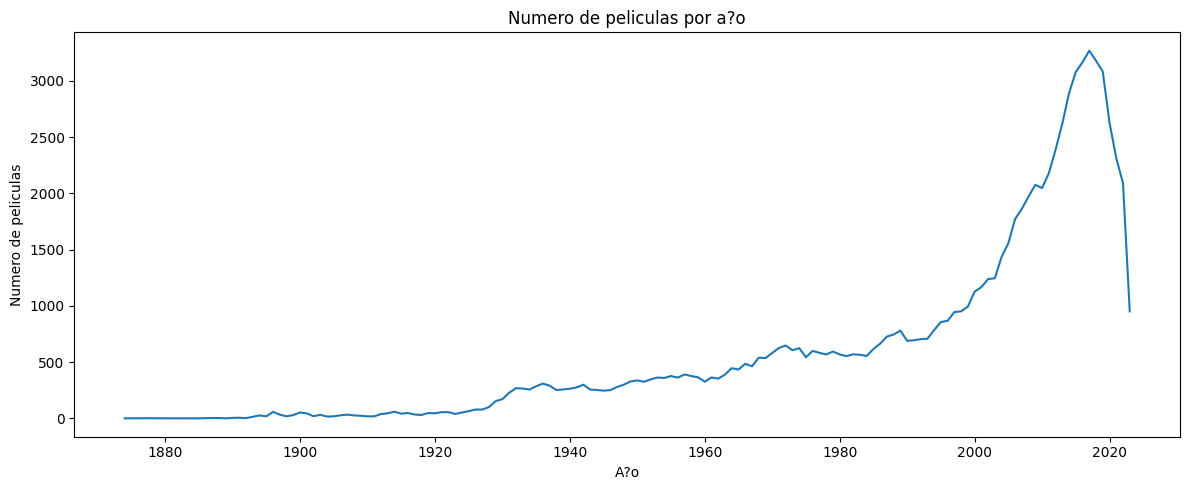

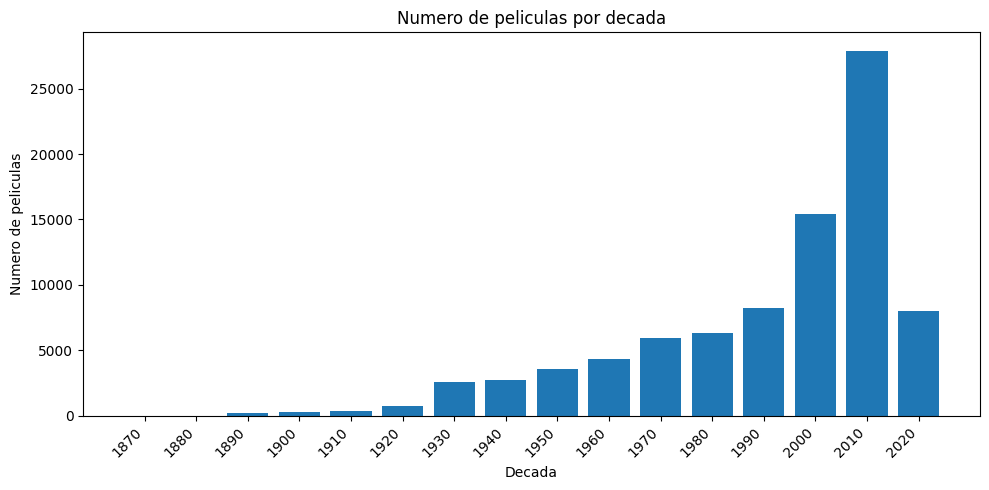

In [10]:
if 'year' in movies_clean.columns:
    movies_with_year = movies_clean.dropna(subset=['year']).copy()
    movies_with_year['year'] = movies_with_year['year'].astype(int)

    movies_by_year = (
        movies_with_year.groupby('year')['movieId']
        .count()
        .reset_index(name='movie_count')
        .sort_values('year')
    )

    movies_with_year['decade'] = (movies_with_year['year'] // 10) * 10
    movies_by_decade = (
        movies_with_year.groupby('decade')['movieId']
        .count()
        .reset_index(name='movie_count')
        .sort_values('decade')
    )

    display(movies_by_year.head())
    display(movies_by_decade)

    plt.figure(figsize=(12, 5))
    plt.plot(movies_by_year['year'], movies_by_year['movie_count'])
    plt.title('Numero de peliculas por a?o')
    plt.xlabel('A?o')
    plt.ylabel('Numero de peliculas')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(movies_by_decade['decade'].astype(str), movies_by_decade['movie_count'])
    plt.title('Numero de peliculas por decada')
    plt.xlabel('Decada')
    plt.ylabel('Numero de peliculas')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('La columna year no esta disponible en el dataset.')

## 11. Guardado de resultados

Guardamos varias tablas resumen para poder reutilizarlas despues en informes, visualizaciones o en la construccion del recomendador.

In [11]:
results_dir.mkdir(parents=True, exist_ok=True)

genre_distribution.to_csv(results_dir / 'genre_distribution.csv', index=False)
top_rated_movies.to_csv(results_dir / 'top_rated_movies.csv', index=False)
most_rated_movies.to_csv(results_dir / 'most_rated_movies.csv', index=False)
ratings_distribution.to_csv(results_dir / 'ratings_distribution.csv', index=False)

print('Resultados guardados en:', results_dir)

Resultados guardados en: C:\Users\alexo\Desktop\TFG\reports\resultados


## 12. Cierre

Este analisis exploratorio ayuda a entender el tamano del dataset, la distribucion de valoraciones, los generos dominantes y la evolucion temporal de las peliculas. Con esta base resulta mas facil justificar las decisiones que se tomen en la siguiente fase del recomendador.